## 01 - Exploratory Data Analysis (EDA)

This notebook loads the **real IEEE-CIS Fraud Detection** training data from `data/raw/`.

In [1]:
import sys
sys.path.insert(0, "D:/mlops4/fraud-mlops")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import load_data, handle_missing_values, encode_categoricals, get_feature_target_split, time_based_train_test_split

TRANSACTIONS_CSV = "D:/mlops4/fraud-mlops/data/raw/train_transaction.csv"
IDENTITY_CSV = "D:/mlops4/fraud-mlops/data/raw/train_identity.csv"

df = load_data(TRANSACTIONS_CSV, IDENTITY_CSV)
df = handle_missing_values(df)
X, y = get_feature_target_split(df)

df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
import seaborn as sns

sns.set_style("whitegrid")

print("Shape:", df.shape)
display(df.dtypes.head(20))
display(df.describe(include="all").transpose().head(20))

Shape: (590540, 220)


TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64
card6                 str
addr1             float64
addr2             float64
P_emaildomain         str
C1                float64
C2                float64
C3                float64
C4                float64
C5                float64
C6                float64
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.358321,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162522,0.251,43.321,68.769,125.0,31937.391
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card1,590540.0,NaN,NaN,NaN,9898.734658,4901.170153,1000.0,6019.0,9678.0,14184.0,18396.0
card2,590540.0,NaN,NaN,NaN,362.531959,156.595356,100.0,215.0,361.0,512.0,600.0
card3,590540.0,NaN,NaN,NaN,153.186458,11.322604,100.0,150.0,150.0,150.0,231.0
card4,590540,5,visa,384767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card5,590540.0,NaN,NaN,NaN,199.471611,41.15761,100.0,166.0,226.0,226.0,237.0


In [3]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

TransactionID     0.0
isFraud           0.0
TransactionDT     0.0
TransactionAmt    0.0
ProductCD         0.0
card1             0.0
card2             0.0
card3             0.0
card4             0.0
card5             0.0
card6             0.0
addr1             0.0
addr2             0.0
P_emaildomain     0.0
C1                0.0
dtype: float64

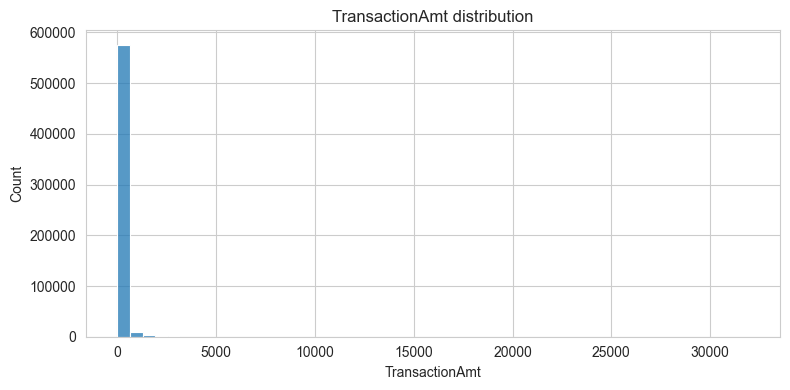

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["TransactionAmt"].astype(float), bins=50)
plt.title("TransactionAmt distribution")
plt.tight_layout()
plt.show()

Fraud rate: 0.0350


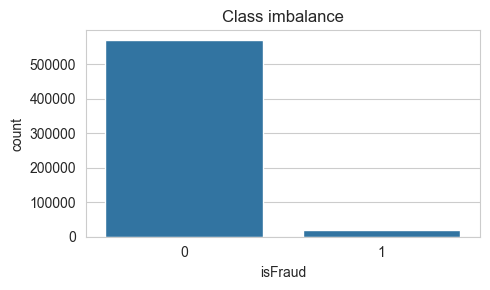

In [5]:
fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.4f}")
plt.figure(figsize=(5, 3))
sns.countplot(x="isFraud", data=df)
plt.title("Class imbalance")
plt.tight_layout()
plt.show()

In [6]:
df_clean = handle_missing_values(df)
print("After missing value handling:", df_clean.shape)
df_clean.isna().sum().sum()

After missing value handling: (590540, 220)


np.int64(0)